# Option Pricing Model Comparison

This notebook compares Black–Scholes, a Cox–Ross–Rubinstein binomial tree,
and Monte Carlo simulation for the same European option.

It also checks convergence, put–call parity, no-arbitrage bounds, and
analytical Greeks against finite-difference estimates.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = Path.cwd().resolve()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.black_scholes import black_scholes_greeks, black_scholes_price
from src.binomial_tree import binomial_price
from src.monte_carlo import monte_carlo_price
from src.validation import (
    benchmark_models,
    finite_difference_greeks,
    no_arbitrage_bounds,
    put_call_parity_gap,
)

## Base option

In [2]:
params = {
    "spot": 100.0,
    "strike": 100.0,
    "maturity": 1.0,
    "rate": 0.05,
    "volatility": 0.20,
    "dividend_yield": 0.00,
}

params

{'spot': 100.0,
 'strike': 100.0,
 'maturity': 1.0,
 'rate': 0.05,
 'volatility': 0.2,
 'dividend_yield': 0.0}

## Compare the three pricing models

In [3]:
results = benchmark_models(
    **params,
    option_type="call",
    tree_steps=500,
    paths=100_000,
    seed=42,
)

comparison = pd.DataFrame(
    {
        "Model": ["Black–Scholes", "Binomial tree", "Monte Carlo"],
        "Price": [
            results["black_scholes"],
            results["binomial"],
            results["monte_carlo"],
        ],
        "Difference from Black–Scholes": [
            0.0,
            results["binomial_error"],
            results["monte_carlo_error"],
        ],
    }
)

comparison.round(6)

,Model,Price,Difference from Black–Scholes
0,Black–Scholes,10.450584,0.000000
1,Binomial tree,10.446585,-0.003998
2,Monte Carlo,10.467314,0.016731


In [4]:
print(
    "Monte Carlo standard error:",
    round(results["monte_carlo_standard_error"], 6),
)

Monte Carlo standard error: 0.033077


## Binomial convergence

In [5]:
bs_price = black_scholes_price(**params, option_type="call")
tree_steps = [5, 10, 25, 50, 100, 250, 500, 1000]

tree_prices = [
    binomial_price(
        **params,
        option_type="call",
        steps=steps,
    )
    for steps in tree_steps
]

tree_results = pd.DataFrame(
    {
        "Steps": tree_steps,
        "Binomial price": tree_prices,
        "Absolute error": np.abs(np.array(tree_prices) - bs_price),
    }
)

tree_results.round(6)

,Steps,Binomial price,Absolute error
0,5,10.805934,0.355350
1,10,10.253409,0.197175
2,25,10.520966,0.070382
3,50,10.410692,0.039892
4,100,10.430612,0.019972
5,250,10.442589,0.007995
6,500,10.446585,0.003998
7,1000,10.448584,0.001999


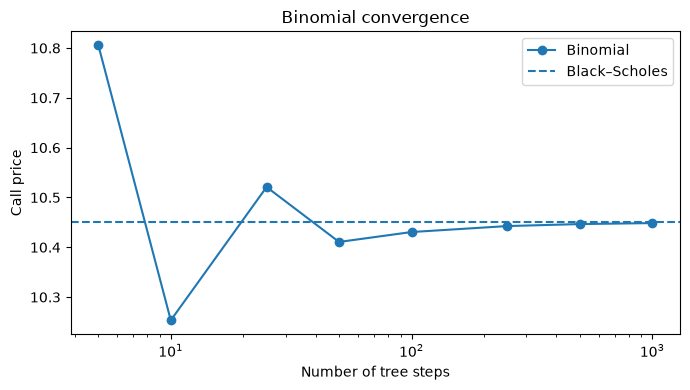

In [6]:
plt.figure(figsize=(7, 4))
plt.plot(tree_steps, tree_prices, marker="o", label="Binomial")
plt.axhline(bs_price, linestyle="--", label="Black–Scholes")
plt.xscale("log")
plt.xlabel("Number of tree steps")
plt.ylabel("Call price")
plt.title("Binomial convergence")
plt.legend()
plt.tight_layout()
plt.show()

## Monte Carlo convergence

In [7]:
path_counts = [1_000, 5_000, 10_000, 50_000, 100_000, 250_000]

mc_rows = []
for paths in path_counts:
    price, standard_error = monte_carlo_price(
        **params,
        option_type="call",
        paths=paths,
        seed=42,
    )
    mc_rows.append(
        {
            "Paths": paths,
            "Price": price,
            "Standard error": standard_error,
            "Absolute error": abs(price - bs_price),
        }
    )

mc_results = pd.DataFrame(mc_rows)
mc_results.round(6)

,Paths,Price,Standard error,Absolute error
0,1000,10.000398,0.313601,0.450186
1,5000,10.450949,0.150468,0.000366
2,10000,10.410052,0.104872,0.040532
3,50000,10.454935,0.046749,0.004352
4,100000,10.467314,0.033077,0.016731
5,250000,10.479143,0.020952,0.028560


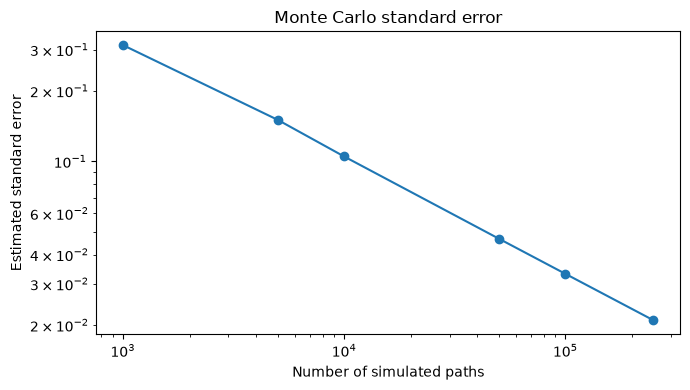

In [8]:
plt.figure(figsize=(7, 4))
plt.plot(mc_results["Paths"], mc_results["Standard error"], marker="o")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Number of simulated paths")
plt.ylabel("Estimated standard error")
plt.title("Monte Carlo standard error")
plt.tight_layout()
plt.show()

## Put–call parity and no-arbitrage checks

In [9]:
call_price = black_scholes_price(**params, option_type="call")
put_price = black_scholes_price(**params, option_type="put")

parity_gap = put_call_parity_gap(
    call_price=call_price,
    put_price=put_price,
    **{
        key: params[key]
        for key in (
            "spot",
            "strike",
            "maturity",
            "rate",
            "dividend_yield",
        )
    },
)

lower, upper = no_arbitrage_bounds(
    **{
        key: params[key]
        for key in (
            "spot",
            "strike",
            "maturity",
            "rate",
            "dividend_yield",
        )
    },
    option_type="call",
)

pd.DataFrame(
    {
        "Check": [
            "Put–call parity gap",
            "Call lower bound",
            "Call price",
            "Call upper bound",
        ],
        "Value": [parity_gap, lower, call_price, upper],
    }
).round(10)

,Check,Value
0,Put–call parity gap,0.000000
1,Call lower bound,4.877058
2,Call price,10.450584
3,Call upper bound,100.000000


## Analytical Greeks versus finite differences

In [10]:
analytical = black_scholes_greeks(**params, option_type="call")
numerical = finite_difference_greeks(**params, option_type="call")

greek_comparison = pd.DataFrame(
    {
        "Analytical": analytical,
        "Finite difference": numerical,
    }
)
greek_comparison["Absolute difference"] = (
    greek_comparison["Analytical"]
    - greek_comparison["Finite difference"]
).abs()

greek_comparison.round(8)

,Analytical,Finite difference,Absolute difference
delta,0.636831,0.636831,1.000000e-08
gamma,0.018762,0.018762,0.000000e+00
vega,37.524035,37.524034,3.000000e-07
theta,-6.414028,-6.414028,0.000000e+00
rho,53.232482,53.232481,7.700000e-07


## Main observations

- The binomial price approaches the Black–Scholes price as the tree becomes finer.
- Monte Carlo precision improves as the number of paths increases.
- Put–call parity and no-arbitrage bounds provide simple independent validation checks.
- Finite-difference Greeks should closely match the analytical Greeks when the step sizes are sensible.